## eda

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set professional styling
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

print("="*80)
print("PHASE 2: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# Load preprocessed data
df = pd.read_csv('new_data/PREPROCESSED.csv')
df['published_at'] = pd.to_datetime(df['published_at'])

print(f"\n📊 Dataset shape: {df.shape}")
print(f"📊 Analysis period: {df['published_at'].min()} to {df['published_at'].max()}")


PHASE 2: EXPLORATORY DATA ANALYSIS (EDA)

📊 Dataset shape: (6952, 26)
📊 Analysis period: 2006-06-27 00:11:00+00:00 to 2025-10-15 15:01:51+00:00



EDA SECTION 1: UNIVARIATE ANALYSIS

[1.1] TARGET VARIABLE DISTRIBUTION:

Virality Distribution (Top 10%):
is_viral
0    6262
1     690
Name: count, dtype: int64

Class Balance:
is_viral
0    0.901
1    0.099
Name: proportion, dtype: float64

[1.2] NUMERICAL FEATURES DISTRIBUTION:


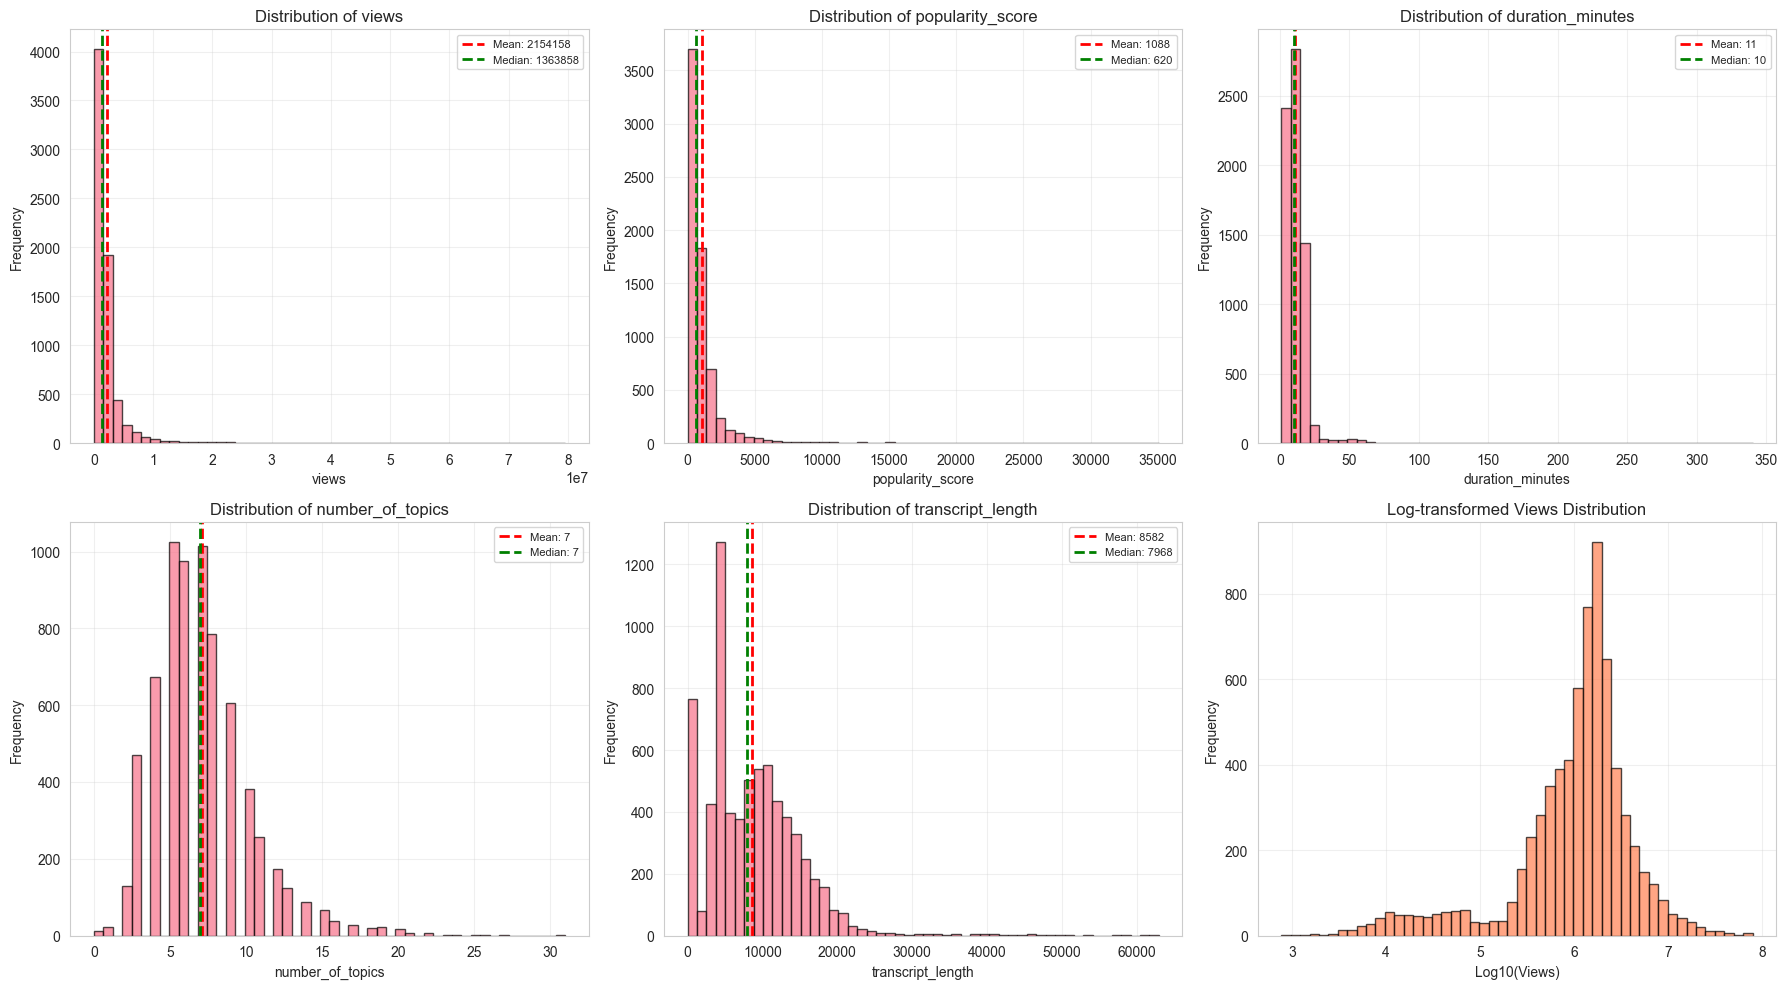

✅ Saved: eda_1_univariate_numerical.png

[1.3] CATEGORICAL FEATURES DISTRIBUTION:


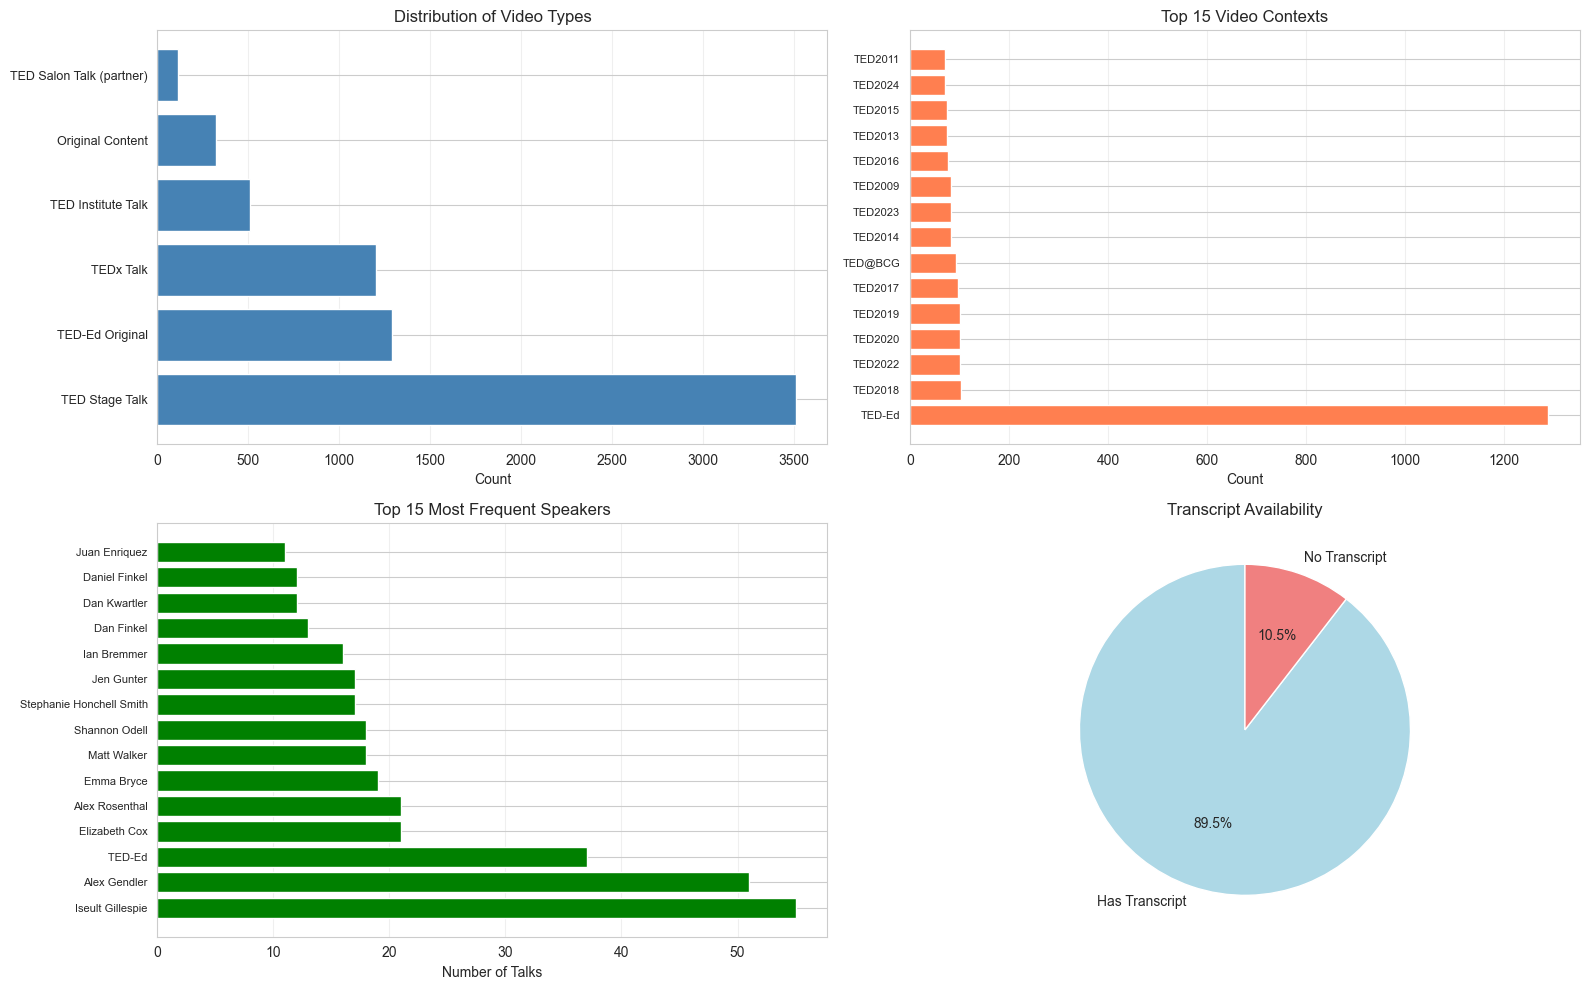

✅ Saved: eda_1_univariate_categorical.png


In [10]:
print("\n" + "="*80)
print("EDA SECTION 1: UNIVARIATE ANALYSIS")
print("="*80)

print("\n[1.1] TARGET VARIABLE DISTRIBUTION:")
print("\nVirality Distribution (Top 10%):")
print(df['is_viral'].value_counts())
print(f"\nClass Balance:")
print(df['is_viral'].value_counts(normalize=True).round(3))

print("\n[1.2] NUMERICAL FEATURES DISTRIBUTION:")
numerical_features = ['views', 'popularity_score', 'duration_minutes', 
                      'number_of_topics', 'transcript_length']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    if col in df.columns:
        # Histogram with KDE
        axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].grid(True, alpha=0.3)
        
        # Add statistics as text
        mean_val = df[col].mean()
        median_val = df[col].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.0f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.0f}')
        axes[idx].legend(fontsize=8)

# Log-transformed distributions
axes[5].hist(np.log10(df['views'] + 1), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[5].set_xlabel('Log10(Views)')
axes[5].set_ylabel('Frequency')
axes[5].set_title('Log-transformed Views Distribution')
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_1_univariate_numerical.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_1_univariate_numerical.png")

print("\n[1.3] CATEGORICAL FEATURES DISTRIBUTION:")

# Key categorical variables
categorical_features = ['type', 'video_context', 'speaker']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Video Type
type_counts = df['type'].value_counts().head(10)
axes[0].barh(range(len(type_counts)), type_counts.values, color='steelblue')
axes[0].set_yticks(range(len(type_counts)))
axes[0].set_yticklabels(type_counts.index, fontsize=9)
axes[0].set_xlabel('Count')
axes[0].set_title('Distribution of Video Types')
axes[0].grid(True, axis='x', alpha=0.3)

# Video Context (top 15)
context_counts = df['video_context'].value_counts().head(15)
axes[1].barh(range(len(context_counts)), context_counts.values, color='coral')
axes[1].set_yticks(range(len(context_counts)))
axes[1].set_yticklabels(context_counts.index, fontsize=8)
axes[1].set_xlabel('Count')
axes[1].set_title('Top 15 Video Contexts')
axes[1].grid(True, axis='x', alpha=0.3)

# Top Speakers (by number of talks)
speaker_counts = df['speaker'].value_counts().head(15)
axes[2].barh(range(len(speaker_counts)), speaker_counts.values, color='green')
axes[2].set_yticks(range(len(speaker_counts)))
axes[2].set_yticklabels(speaker_counts.index, fontsize=8)
axes[2].set_xlabel('Number of Talks')
axes[2].set_title('Top 15 Most Frequent Speakers')
axes[2].grid(True, axis='x', alpha=0.3)

# Has Transcript distribution
transcript_dist = df['has_transcript'].value_counts()
axes[3].pie(transcript_dist.values, labels=['Has Transcript', 'No Transcript'], 
            autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
axes[3].set_title('Transcript Availability')

plt.tight_layout()
plt.savefig('eda_1_univariate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_1_univariate_categorical.png")



EDA SECTION 2: BIVARIATE ANALYSIS (Target vs Features)

[2.1] VIRAL vs NON-VIRAL: NUMERICAL FEATURES

Statistical Comparison:
               views                         popularity_score           \
                mean     median          std             mean   median   
is_viral                                                                 
0         1522522.17  1292006.0   1390265.04           666.81   511.98   
1         7886483.25  5152373.0  10350507.04          4907.85  3614.02   

                  duration_minutes               number_of_topics         \
              std             mean median    std             mean median   
is_viral                                                                   
0          539.86            11.15   11.0   8.23             7.09    7.0   
1         3812.71            10.16    5.0  10.90             7.36    7.0   

               transcript_length                   
           std              mean  median      std  
is_viral         

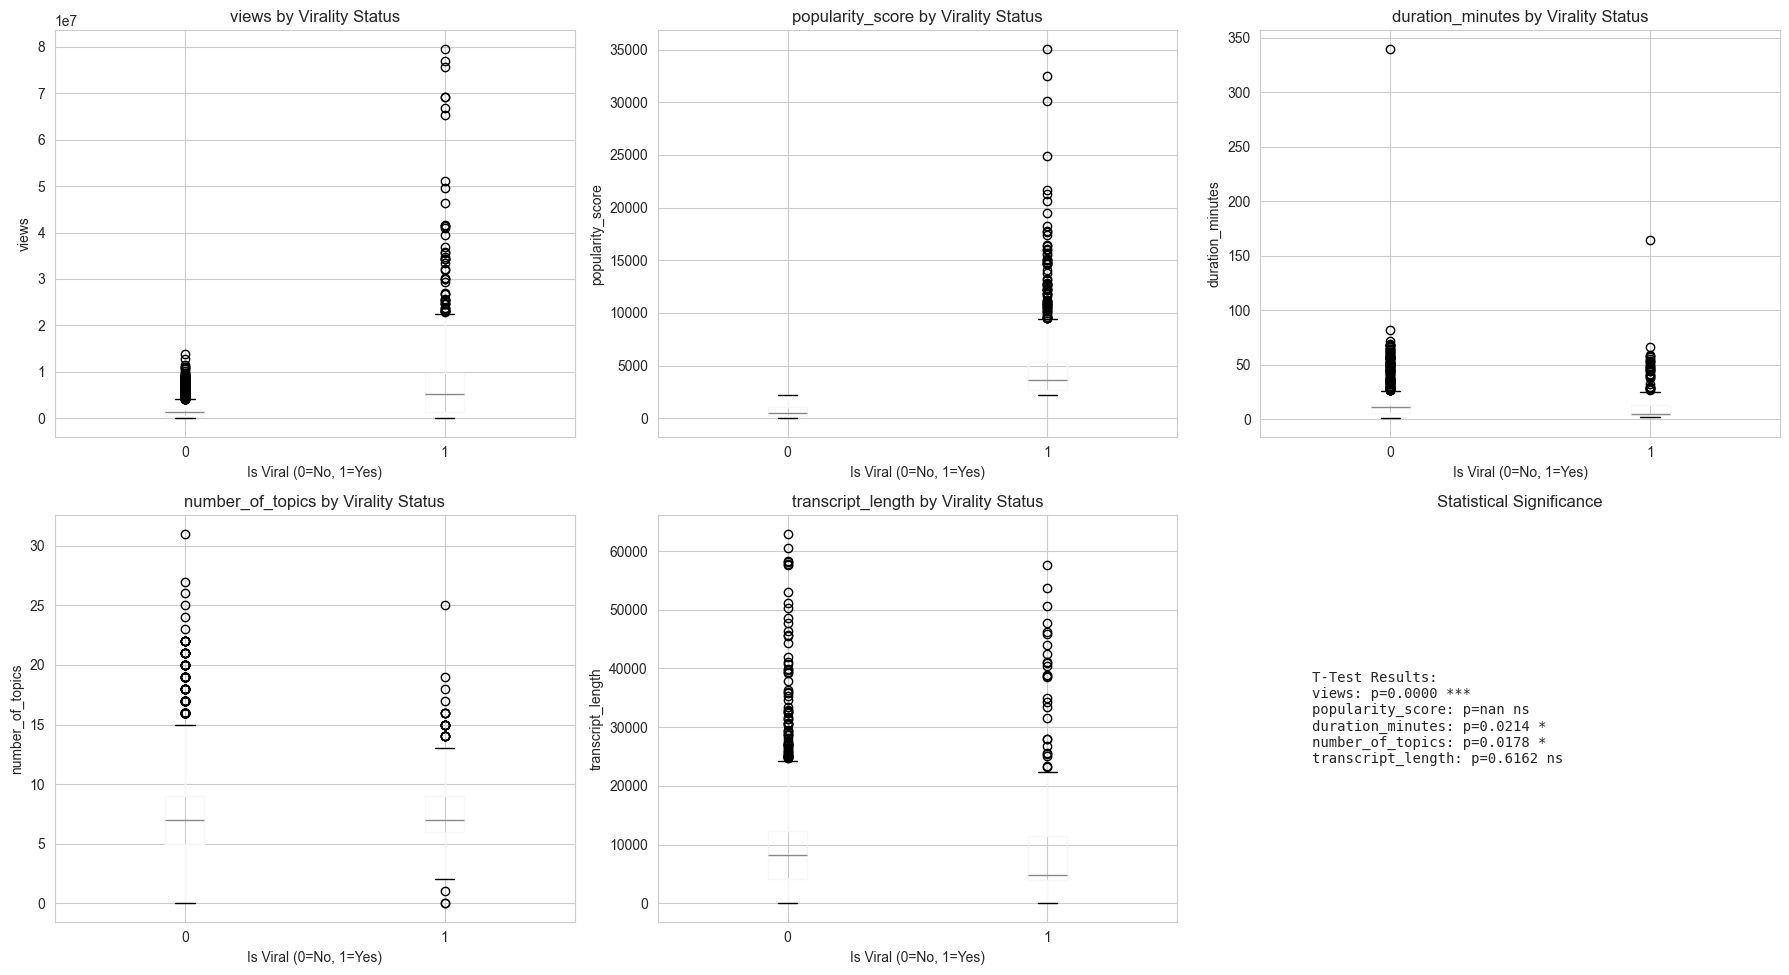

✅ Saved: eda_2_bivariate_numerical.png

[2.2] VIRAL vs NON-VIRAL: CATEGORICAL FEATURES


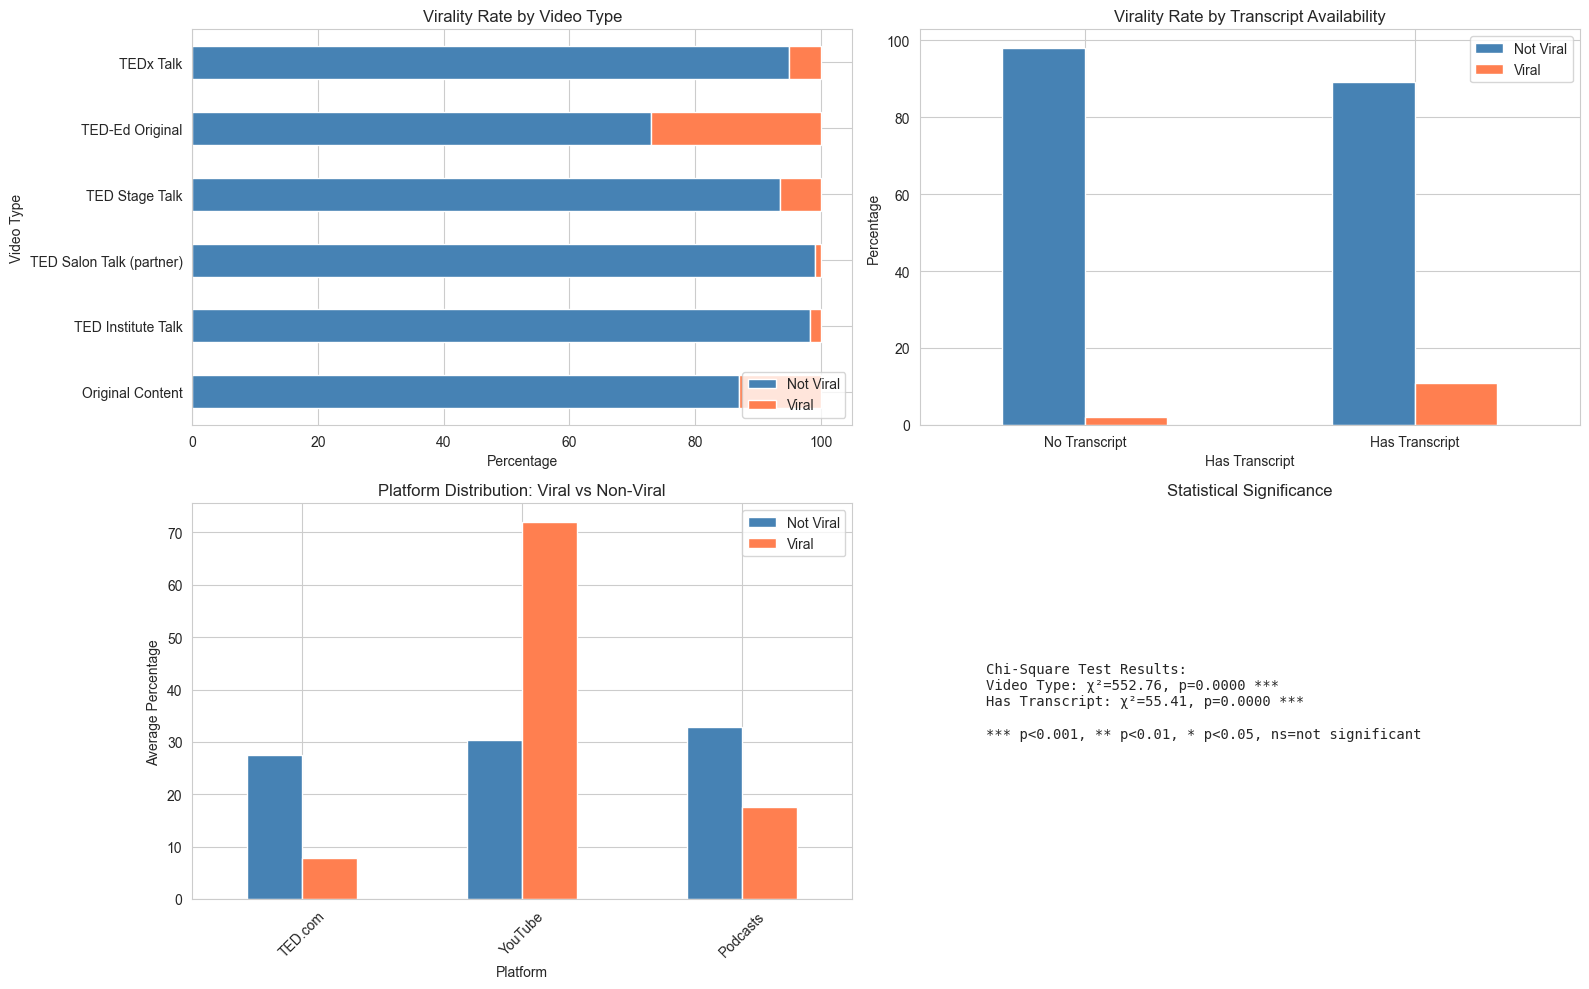

✅ Saved: eda_2_bivariate_categorical.png to analysis folder


In [11]:
print("\n" + "="*80)
print("EDA SECTION 2: BIVARIATE ANALYSIS (Target vs Features)")
print("="*80)

print("\n[2.1] VIRAL vs NON-VIRAL: NUMERICAL FEATURES")

# Statistical comparison
comparison_stats = df.groupby('is_viral').agg({
    'views': ['mean', 'median', 'std'],
    'popularity_score': ['mean', 'median', 'std'],
    'duration_minutes': ['mean', 'median', 'std'],
    'number_of_topics': ['mean', 'median', 'std'],
    'transcript_length': ['mean', 'median', 'std']
}).round(2)

print("\nStatistical Comparison:")
print(comparison_stats)

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

numerical_compare = ['views', 'popularity_score', 'duration_minutes', 
                     'number_of_topics', 'transcript_length']

for idx, col in enumerate(numerical_compare):
    if col in df.columns:
        df.boxplot(column=col, by='is_viral', ax=axes[idx])
        axes[idx].set_xlabel('Is Viral (0=No, 1=Yes)')
        axes[idx].set_ylabel(col)
        axes[idx].set_title(f'{col} by Virality Status')
        axes[idx].get_figure().suptitle('')  # Remove default title

# T-test results
axes[5].axis('off')
t_test_results = []
for col in numerical_compare:
    if col in df.columns:
        viral = df[df['is_viral']==1][col]
        non_viral = df[df['is_viral']==0][col]
        t_stat, p_value = stats.ttest_ind(viral, non_viral, equal_var=False)
        t_test_results.append(f"{col}: p={p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

axes[5].text(0.1, 0.5, "T-Test Results:\n" + "\n".join(t_test_results), 
             fontsize=10, verticalalignment='center', family='monospace')
axes[5].set_title('Statistical Significance')

plt.tight_layout()
plt.savefig('eda_2_bivariate_numerical.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_2_bivariate_numerical.png")

print("\n[2.2] VIRAL vs NON-VIRAL: CATEGORICAL FEATURES")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Video Type vs Virality
type_viral = df.groupby(['type', 'is_viral']).size().unstack(fill_value=0)
type_viral_pct = type_viral.div(type_viral.sum(axis=1), axis=0) * 100
type_viral_pct.plot(kind='barh', stacked=True, ax=axes[0], 
                    color=['steelblue', 'coral'], legend=True)
axes[0].set_xlabel('Percentage')
axes[0].set_ylabel('Video Type')
axes[0].set_title('Virality Rate by Video Type')
axes[0].legend(['Not Viral', 'Viral'], loc='lower right')

# Has Transcript vs Virality
transcript_viral = df.groupby(['has_transcript', 'is_viral']).size().unstack(fill_value=0)
transcript_viral_pct = transcript_viral.div(transcript_viral.sum(axis=1), axis=0) * 100
transcript_viral_pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_xlabel('Has Transcript')
axes[1].set_ylabel('Percentage')
axes[1].set_title('Virality Rate by Transcript Availability')
axes[1].set_xticklabels(['No Transcript', 'Has Transcript'], rotation=0)
axes[1].legend(['Not Viral', 'Viral'])

# Platform Distribution
platform_cols = ['tedcom_percentage', 'youtube_percentage', 'podcasts_percentage']
platform_viral = df.groupby('is_viral')[platform_cols].mean() * 100
platform_viral.T.plot(kind='bar', ax=axes[2], color=['steelblue', 'coral'])
axes[2].set_xlabel('Platform')
axes[2].set_ylabel('Average Percentage')
axes[2].set_title('Platform Distribution: Viral vs Non-Viral')
axes[2].set_xticklabels(['TED.com', 'YouTube', 'Podcasts'], rotation=45)
axes[2].legend(['Not Viral', 'Viral'])

# Chi-square test results
axes[3].axis('off')
chi_results = []

# Video type
contingency_type = pd.crosstab(df['type'], df['is_viral'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_type)
chi_results.append(f"Video Type: χ²={chi2:.2f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

# Has transcript
contingency_trans = pd.crosstab(df['has_transcript'], df['is_viral'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_trans)
chi_results.append(f"Has Transcript: χ²={chi2:.2f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

axes[3].text(0.1, 0.5, "Chi-Square Test Results:\n" + "\n".join(chi_results) + 
             "\n\n*** p<0.001, ** p<0.01, * p<0.05, ns=not significant",
             fontsize=10, verticalalignment='center', family='monospace')
axes[3].set_title('Statistical Significance')

plt.tight_layout()
plt.savefig('analysis/eda_2_bivariate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_2_bivariate_categorical.png to analysis folder")



EDA SECTION 3: TEMPORAL ANALYSIS

[3.1] TEMPORAL TRENDS:


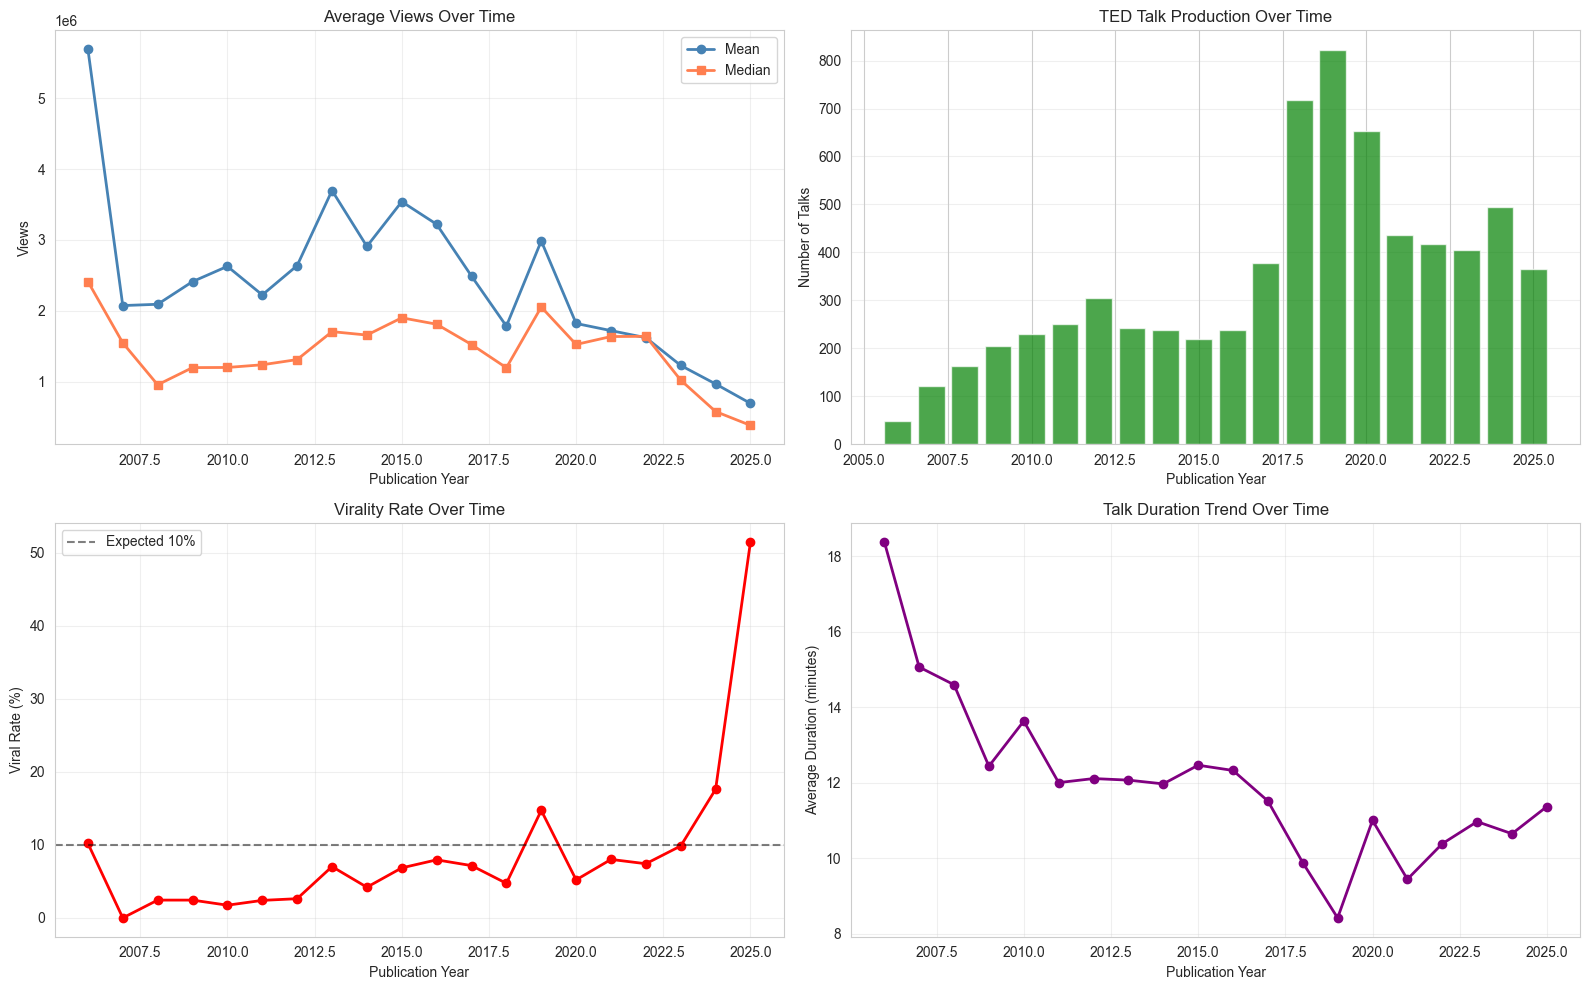

✅ Saved: eda_3_temporal_analysis.png to folder analysis


In [12]:
print("\n" + "="*80)
print("EDA SECTION 3: TEMPORAL ANALYSIS")
print("="*80)

df['publication_year'] = df['published_at'].dt.year
df['publication_month'] = df['published_at'].dt.month

print("\n[3.1] TEMPORAL TRENDS:")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Views over time
yearly_views = df.groupby('publication_year').agg({
    'views': ['mean', 'median'],
    'id': 'count'
}).reset_index()
yearly_views.columns = ['year', 'mean_views', 'median_views', 'count']

axes[0, 0].plot(yearly_views['year'], yearly_views['mean_views'], 
                marker='o', linewidth=2, label='Mean', color='steelblue')
axes[0, 0].plot(yearly_views['year'], yearly_views['median_views'], 
                marker='s', linewidth=2, label='Median', color='coral')
axes[0, 0].set_xlabel('Publication Year')
axes[0, 0].set_ylabel('Views')
axes[0, 0].set_title('Average Views Over Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Production over time
axes[0, 1].bar(yearly_views['year'], yearly_views['count'], color='green', alpha=0.7)
axes[0, 1].set_xlabel('Publication Year')
axes[0, 1].set_ylabel('Number of Talks')
axes[0, 1].set_title('TED Talk Production Over Time')
axes[0, 1].grid(True, axis='y', alpha=0.3)

# Virality rate over time
viral_by_year = df.groupby('publication_year')['is_viral'].agg(['sum', 'count'])
viral_by_year['viral_rate'] = (viral_by_year['sum'] / viral_by_year['count']) * 100

axes[1, 0].plot(viral_by_year.index, viral_by_year['viral_rate'], 
                marker='o', linewidth=2, color='red')
axes[1, 0].set_xlabel('Publication Year')
axes[1, 0].set_ylabel('Viral Rate (%)')
axes[1, 0].set_title('Virality Rate Over Time')
axes[1, 0].axhline(10, color='black', linestyle='--', alpha=0.5, label='Expected 10%')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Duration trends
duration_by_year = df.groupby('publication_year')['duration_minutes'].mean()
axes[1, 1].plot(duration_by_year.index, duration_by_year.values, 
                marker='o', linewidth=2, color='purple')
axes[1, 1].set_xlabel('Publication Year')
axes[1, 1].set_ylabel('Average Duration (minutes)')
axes[1, 1].set_title('Talk Duration Trend Over Time')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analysis/eda_3_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_3_temporal_analysis.png to folder analysis")


EDA SECTION 4: CORRELATION ANALYSIS

[4.1] CORRELATION MATRIX:


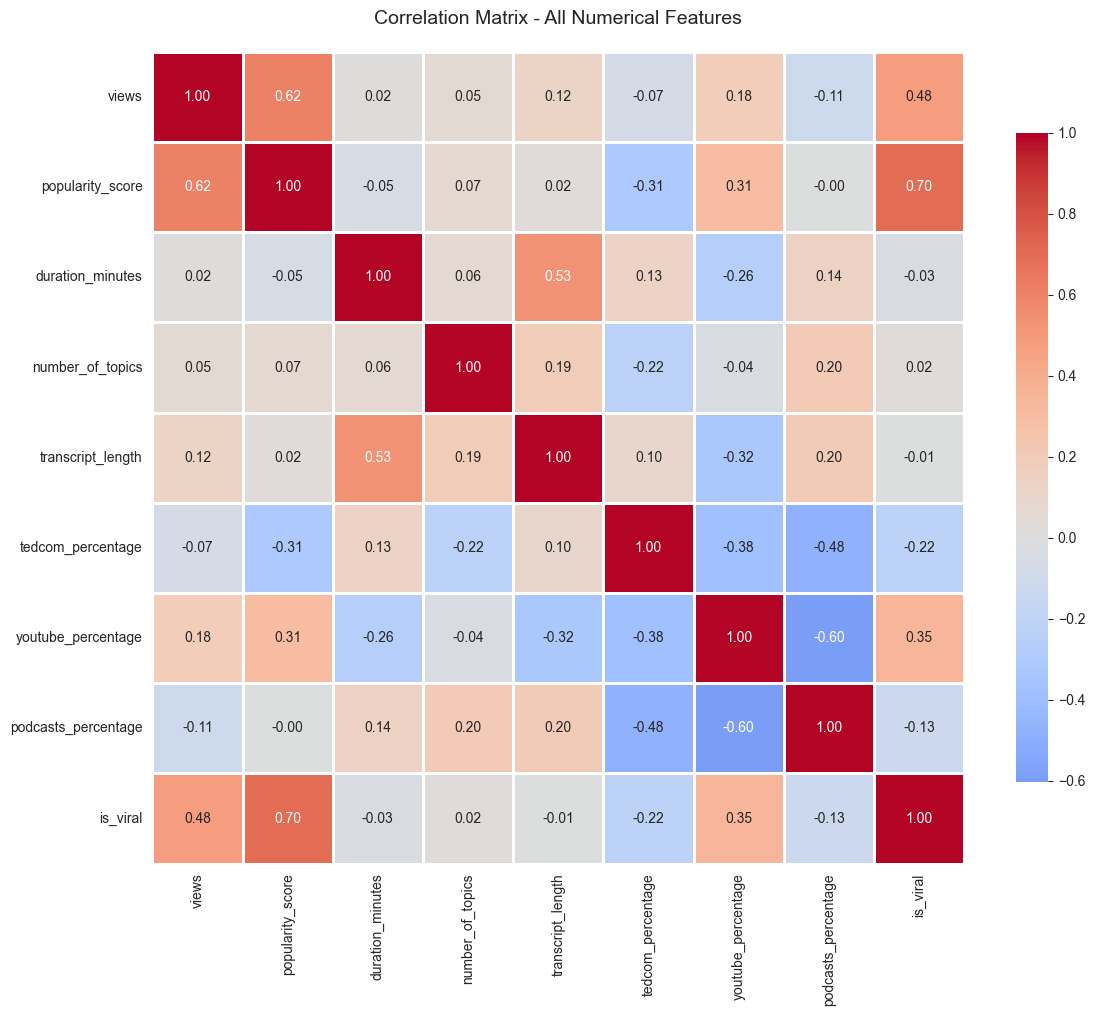

✅ Saved: eda_4_correlation_matrix.png

[4.2] STRONGEST CORRELATIONS WITH VIRALITY:
is_viral               1.000000
popularity_score       0.696871
views                  0.476015
youtube_percentage     0.347448
tedcom_percentage      0.219270
podcasts_percentage    0.128275
duration_minutes       0.034552
number_of_topics       0.024915
transcript_length      0.007021
Name: is_viral, dtype: float64


In [13]:
print("\n" + "="*80)
print("EDA SECTION 4: CORRELATION ANALYSIS")
print("="*80)

print("\n[4.1] CORRELATION MATRIX:")

# Select numerical features for correlation
corr_features = ['views', 'popularity_score', 'duration_minutes', 'number_of_topics',
                 'transcript_length', 'tedcom_percentage', 'youtube_percentage', 
                 'podcasts_percentage', 'is_viral']

corr_features = [f for f in corr_features if f in df.columns]
correlation_matrix = df[corr_features].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=ax)
ax.set_title('Correlation Matrix - All Numerical Features', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('analysis/eda_4_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_4_correlation_matrix.png")

# Find strongest correlations with target
print("\n[4.2] STRONGEST CORRELATIONS WITH VIRALITY:")
target_corr = correlation_matrix['is_viral'].abs().sort_values(ascending=False)
print(target_corr.head(10))


[5.1] EXTRACTING TOPICS (REFINED):
Total unique topics: 362

Top 20 most common topics (Excluding {'TED Brain Trust', 'TED-Ed', 'TED Fellows', 'TEDx'}):
  science                       : 1632 (23.5%)
  technology                    : 1575 (22.7%)
  education                     : 1254 (18.0%)
  animation                     : 1228 (17.7%)
  social change                 : 1042 (15.0%)
  culture                       :  970 (14.0%)
  society                       :  816 (11.7%)
  business                      :  809 (11.6%)
  health                        :  809 (11.6%)
  history                       :  791 (11.4%)
  global issues                 :  730 (10.5%)
  design                        :  655 (9.4%)
  innovation                    :  638 (9.2%)
  climate change                :  605 (8.7%)
  humanity                      :  588 (8.5%)
  biology                       :  574 (8.3%)
  personal growth               :  571 (8.2%)
  communication                 :  546 (7.9%)
  art  

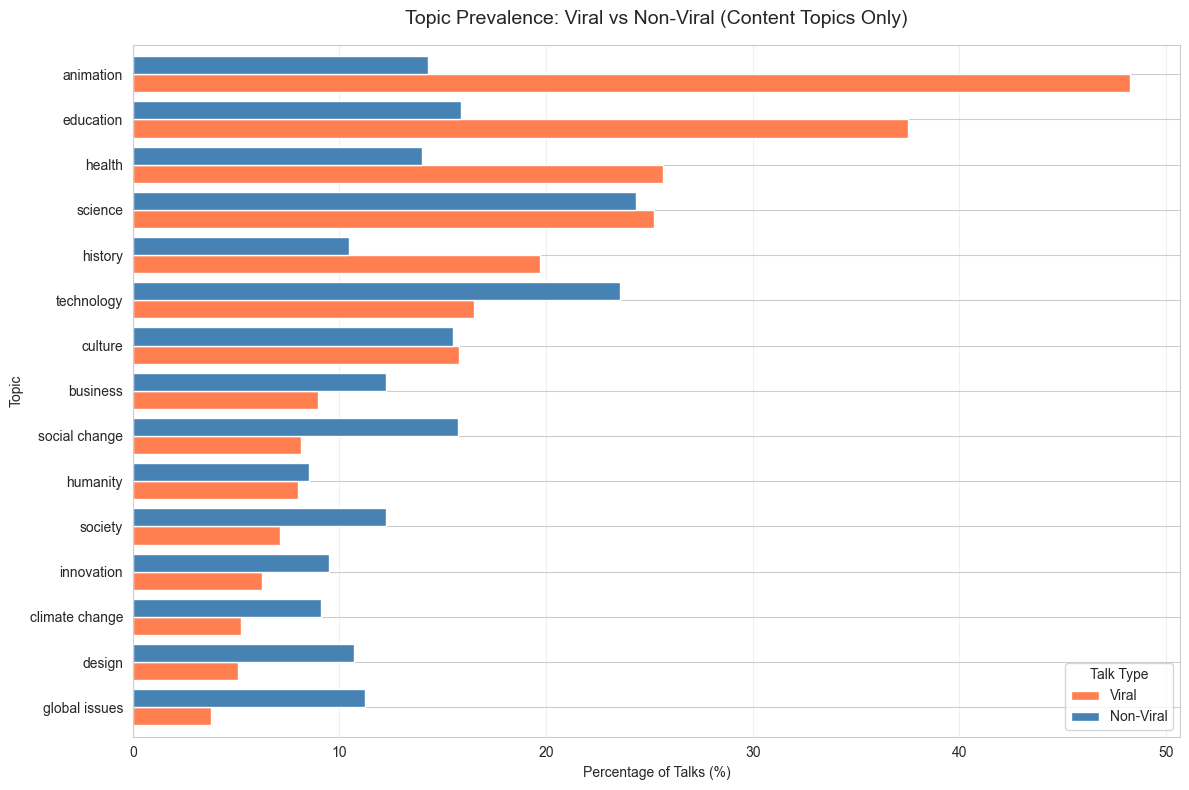

In [16]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# [5.1] REFINED TOPIC EXTRACTION
print("\n[5.1] EXTRACTING TOPICS (REFINED):")

# Define non-topic tags to exclude
tags_to_exclude = {'TED-Ed', 'TEDx', 'TED Fellows', 'TED Brain Trust'}

all_topics_refined = []
# Filter topics loop
for topics_str in df['topics'].dropna():
    if topics_str != 'Unknown':
        # Split string into list
        current_topics = [t.strip() for t in str(topics_str).split(',')]
        # Keep only topics NOT in the exclusion list
        filtered_topics = [t for t in current_topics if t not in tags_to_exclude]
        all_topics_refined.extend(filtered_topics)

# Count and display
topic_counts_refined = Counter(all_topics_refined)
top_topics_refined = topic_counts_refined.most_common(20)

print(f"Total unique topics: {len(topic_counts_refined)}")
print(f"\nTop 20 most common topics (Excluding {tags_to_exclude}):")
for topic, count in top_topics_refined[:20]:
    print(f"  {topic:30s}: {count:4d} ({count/len(df)*100:.1f}%)")

# [5.2] VISUALIZATION
print("\n[5.2] TOPIC PREVALENCE: VIRAL vs NON-VIRAL (REFINED)")

popular_topics_refined = [t[0] for t in top_topics_refined[:15]]
topic_comparison_refined = {}

for topic in popular_topics_refined:
    # Calculate percentages for viral and non-viral groups
    viral_pct = df[df['is_viral']==1]['topics'].str.contains(topic, case=False, na=False).mean() * 100
    non_viral_pct = df[df['is_viral']==0]['topics'].str.contains(topic, case=False, na=False).mean() * 100
    topic_comparison_refined[topic] = {'Viral': viral_pct, 'Non-Viral': non_viral_pct}

# Create DataFrame and Plot
topic_df_refined = pd.DataFrame(topic_comparison_refined).T.sort_values('Viral', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
topic_df_refined.plot(kind='barh', ax=ax, color=['coral', 'steelblue'], width=0.8)
ax.set_xlabel('Percentage of Talks (%)')
ax.set_ylabel('Topic')
ax.set_title('Topic Prevalence: Viral vs Non-Viral (Content Topics Only)', fontsize=14, pad=15)
ax.legend(title='Talk Type', loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
print("\n" + "="*80)
print("EDA SECTION 6: KEY INSIGHTS SUMMARY")
print("="*80)

insights = {
    "Target Variable": {
        "Viral (Top 10%)": f"{(df['is_viral']==1).sum()} talks ({(df['is_viral']==1).mean()*100:.1f}%)",
        "Non-Viral": f"{(df['is_viral']==0).sum()} talks ({(df['is_viral']==0).mean()*100:.1f}%)",
        "Threshold": f"{df['popularity_score'].quantile(0.90):.2f} views/day"
    },
    "Viral vs Non-Viral Differences": {
        "Mean Views": f"{df[df['is_viral']==1]['views'].mean()/df[df['is_viral']==0]['views'].mean():.2f}x higher",
        "Median Duration": f"{df[df['is_viral']==0]['duration_minutes'].median():.1f} vs {df[df['is_viral']==1]['duration_minutes'].median():.1f} min",
        "YouTube %": f"{df[df['is_viral']==1]['youtube_percentage'].mean()*100:.1f}% vs {df[df['is_viral']==0]['youtube_percentage'].mean()*100:.1f}%"
    },
    "Temporal Trends": {
        "Peak Production": f"{yearly_views.loc[yearly_views['count'].idxmax(), 'year']:.0f} ({yearly_views['count'].max():.0f} talks)",
        "Views Trend": "Declining over time (temporal bias)",
        "Duration Trend": "Decreasing (18min → 12min)"
    },
    "Top Predictors": {
        "Correlation with Virality": target_corr.head(5).to_dict()
    }
}

print("\n📊 KEY INSIGHTS:")
for category, details in insights.items():
    print(f"\n{category}:")
    for key, value in details.items():
        print(f"  • {key}: {value}")

# Save insights to JSON
import json
with open('eda_insights.json', 'w') as f:
    json.dump(insights, f, indent=2, default=str)

print("\n✅ Saved: eda_insights.json")

print("\n" + "="*80)
print("EDA COMPLETE!")
print("="*80)
print("\n📁 Generated files:")
print("  1. eda_1_univariate_numerical.png")
print("  2. eda_1_univariate_categorical.png")
print("  3. eda_2_bivariate_numerical.png")
print("  4. eda_2_bivariate_categorical.png")
print("  5. eda_3_temporal_analysis.png")
print("  6. eda_4_correlation_matrix.png")
print("  7. eda_5_topic_analysis.png")
print("  8. eda_insights.json")
print("\n✅ Ready for Feature Engineering & Modeling!")


EDA SECTION 6: KEY INSIGHTS SUMMARY

📊 KEY INSIGHTS:

Target Variable:
  • Viral (Top 10%): 690 talks (9.9%)
  • Non-Viral: 6262 talks (90.1%)
  • Threshold: 2149.93 views/day

Viral vs Non-Viral Differences:
  • Mean Views: 5.18x higher
  • Median Duration: 11.0 vs 5.0 min
  • YouTube %: 71.9% vs 30.4%

Temporal Trends:
  • Peak Production: 2019 (822 talks)
  • Views Trend: Declining over time (temporal bias)
  • Duration Trend: Decreasing (18min → 12min)

Top Predictors:
  • Correlation with Virality: {'is_viral': 1.0, 'popularity_score': 0.6968708039084077, 'views': 0.4760154590778609, 'youtube_percentage': 0.34744814535529894, 'tedcom_percentage': 0.2192701410351056}

✅ Saved: eda_insights.json

EDA COMPLETE!

📁 Generated files:
  1. eda_1_univariate_numerical.png
  2. eda_1_univariate_categorical.png
  3. eda_2_bivariate_numerical.png
  4. eda_2_bivariate_categorical.png
  5. eda_3_temporal_analysis.png
  6. eda_4_correlation_matrix.png
  7. eda_5_topic_analysis.png
  8. eda_insi